# Курсовая работа. Блок ML Beginner

**Описание работы:**
&nbsp;&nbsp;&nbsp;&nbsp;
<br><br>
&nbsp;&nbsp;&nbsp;&nbsp; Любой бизнес хочет максимизировать количество клиентов. Для достижения этой цели важно не только пытаться привлечь новых, но и удерживать уже существующих. Удержать клиента обойдется компании дешевле, чем привлечь нового. Кроме того, новый клиент может оказаться слабо заинтересованным в услугах бизнеса и с ним будет сложно работать, тогда как о старых клиентах уже есть необходимые данные по взаимодействию с сервисом.
 <br>

&nbsp;&nbsp;&nbsp;&nbsp; Соответственно, прогнозируя отток, мы можем вовремя среагировать и попытаться удержать клиента, который хочет уйти. Опираясь на данные об услугах, которыми пользуется клиент, мы можем сделать ему специальное предложение, пытаясь изменить его решение об уходе от оператора. Благодаря этому задача удержания будет легче в реализации, чем задача привлечения новых пользователей, о которых мы еще ничего не знаем.<br>

&nbsp;&nbsp;&nbsp;&nbsp; Вам предоставлен набор данных от телекоммуникационной компании. В данных содержится информация о почти шести тысячах пользователей, их демографических характеристиках, услугах, которыми они пользуются, длительности пользования услугами оператора, методе оплаты, размере оплаты.
<br>

&nbsp;&nbsp;&nbsp;&nbsp; Cтоит задача проанализировать данные и спрогнозировать отток пользователей (выявить людей, которые продлят контракт и которые не продлят). Работа должна включать в себя следующие обязательные пункты:
1. Описание данных *(с расчетом базовых статистик)*,
2. Исследование зависимостей и формулирование гипотез,
3. Построение моделей для прогнозирования оттока *(с обоснованием выбора той или иной модели)* на основе проверенных гипотез и выявленных взаимосвязей,
4. Сравнение качества полученных моделей.

Во втором разделе обязательно должно присутствовать обоснование гипотез, подробное описание выявленных взаимосвязей, а также их визуализация.
<br>В четвертом дополнительно должны быть сформулированы общие выводы работы.

<br><br>

_________

[Codebook](#Codebook) <br>
[1. Описание данных](#1.-Описание-данных)<br>
[2. Исследование зависимостей и формулирование гипотез](#2.-Исследование-зависимостей-и-формулирование-гипотез)<br>
[3. Построение моделей для прогнозирования оттока](#3.-Построение-моделей-для-прогнозирования-оттока)<br>
[4. Сравнение качества моделей](#4.-Сравнение-качества-моделей) <br>


## Codebook
<br>

[Ссылка для скачивания данных](https://drive.google.com/open?id=1dPCG76ST6NohYKtVMGv6HpFL-jD5p1eJ)
<br><br>

`telecom_users.csv` содержит следующие значения:<br><br>

&nbsp;&nbsp;&nbsp;&nbsp; `customerID` – id клиента<br>
&nbsp;&nbsp;&nbsp;&nbsp; `gender` – пол клиента (male/female)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `SeniorCitizen` – яляется ли клиент пенсионером (1, 0)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `Partner` – состоит ли клиент в браке (Yes, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `Dependents` – есть ли у клиента иждивенцы (Yes, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `tenure` – сколько месяцев человек являлся клиентом компании<br>
&nbsp;&nbsp;&nbsp;&nbsp; `PhoneService` – подключена ли услуга телефонной связи (Yes, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `MultipleLines` – подключены ли несколько телефонных линий (Yes, No, No phone service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `InternetService` – интернет-провайдер клиента (DSL, Fiber optic, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `OnlineSecurity` – подключена ли услуга онлайн-безопасности (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `OnlineBackup` – подключена ли услуга online backup (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `DeviceProtection` – есть ли у клиента страховка оборудования (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `TechSupport` – подключена ли услуга технической поддержки (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `StreamingTV` – подключена ли услуга стримингового телевидения (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `StreamingMovies` – подключена ли услуга стримингового кинотеатра (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `Contract` – тип контракта клиента (Month-to-month, One year, Two year)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `PaperlessBilling` – пользуется ли клиент безбумажным биллингом (Yes, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `PaymentMethod` – метод оплаты (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))<br>
&nbsp;&nbsp;&nbsp;&nbsp; `MonthlyCharges` – месячный размер оплаты на настоящий момент<br>
&nbsp;&nbsp;&nbsp;&nbsp; `TotalCharges` – общая сумма, которую клиент заплатил за услуги за все время<br>
&nbsp;&nbsp;&nbsp;&nbsp; `Churn` – произошел ли отток (Yes or No)<br>

# 1. Описание данных

In [1]:
# Загружаем библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Загрузим датафрейм? отсортируем строки по индексу и выведем первые пять строк на экран
df = pd.read_csv('telecom_users.csv', index_col=0)
df = df.sort_index()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Проверяем типы данных для колонок, а также есть ли отсутствующие значения в датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5986 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5986 non-null   object 
 1   gender            5986 non-null   object 
 2   SeniorCitizen     5986 non-null   int64  
 3   Partner           5986 non-null   object 
 4   Dependents        5986 non-null   object 
 5   tenure            5986 non-null   int64  
 6   PhoneService      5986 non-null   object 
 7   MultipleLines     5986 non-null   object 
 8   InternetService   5986 non-null   object 
 9   OnlineSecurity    5986 non-null   object 
 10  OnlineBackup      5986 non-null   object 
 11  DeviceProtection  5986 non-null   object 
 12  TechSupport       5986 non-null   object 
 13  StreamingTV       5986 non-null   object 
 14  StreamingMovies   5986 non-null   object 
 15  Contract          5986 non-null   object 
 16  PaperlessBilling  5986 non-null   object 
 17  

In [4]:
# Выведем статистические метрики для числовых колонок
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5986.0,0.161377,0.367909,0.00,0.00,0.0,0.0,1.00
tenure,5986.0,32.468760,24.516391,0.00,9.00,29.0,56.0,72.00
MonthlyCharges,5986.0,64.802213,30.114702,18.25,35.65,70.4,89.9,118.75


Большинство колонок являются категориальными. Позднее нужно будет создать для них дамми-переменные.
Также мы видим, что колонка **TotalCharges** должна быть численной, но имеет тип *object*, что говорит о том что часть данных в данной колонке не была преобразована в числовой тип при выгрузке из-за аномалий

In [5]:
# Выгрузим строки с пустыми значениями в TotalCharges
df[df['TotalCharges'].str.isspace()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6754,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,,No


Как можно увидеть из таблицы - пустые строки в **TotalCharges** соответствуют значениям 0 в колонке **tenure**, т.е. новые клиенты, еще не оплатившие услуги или оплата еще не была учтена. Мы можем отбросить эти строки, они в данный момент не представляют интереса

In [6]:
# Отбрасываем значения с пустыми строками в TotalCharges
df = df[~df['TotalCharges'].str.isspace()]
# Приводим колонку TotalCharges к типу float
df['TotalCharges'] = df['TotalCharges'].astype(float)
# Выведем статистические метрики для числовых колонок теперь
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5976.0,0.161647,0.368157,0.00,0.0000,0.000,0.0000,1.00
tenure,5976.0,32.523092,24.500858,1.00,9.0000,29.000,56.0000,72.00
MonthlyCharges,5976.0,64.846687,30.107576,18.25,35.7500,70.425,89.9000,118.75
TotalCharges,5976.0,2298.060617,2274.127165,18.80,404.3125,1412.150,3846.9625,8684.80


# 2. Исследование зависимостей и формулирование гипотез

## 2.1 Построим график CountPlot для проверки сбалансированности значений колонки с классами (Churn)

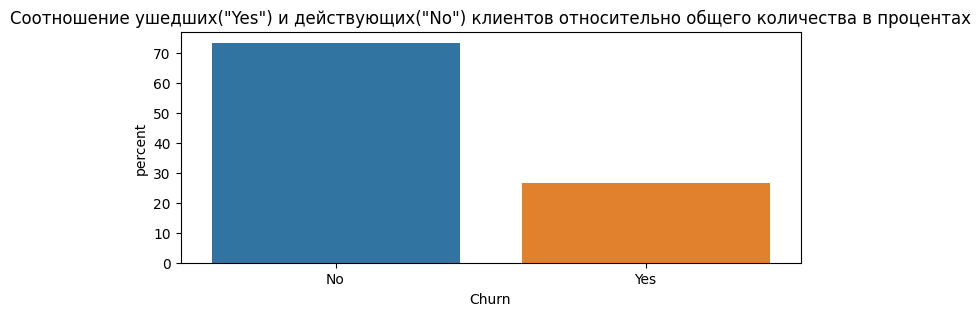

In [7]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='Churn', hue='Churn', stat="percent")
plt.title('Соотношение ушедших("Yes") и действующих("No") клиентов относительно общего количества в процентах');

## 2.2 Исследуем распределение колонки TotalCharges по различным категориям Churn

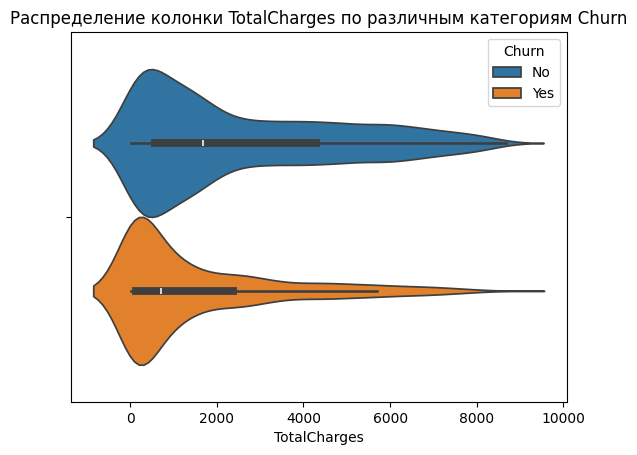

In [8]:
sns.violinplot(data=df, x='TotalCharges', hue='Churn')
plt.title('Распределение колонки TotalCharges по различным категориям Churn');

## 2.3 Построим график boxplot с распределением колонки TotalCharges для различных типов контрактов

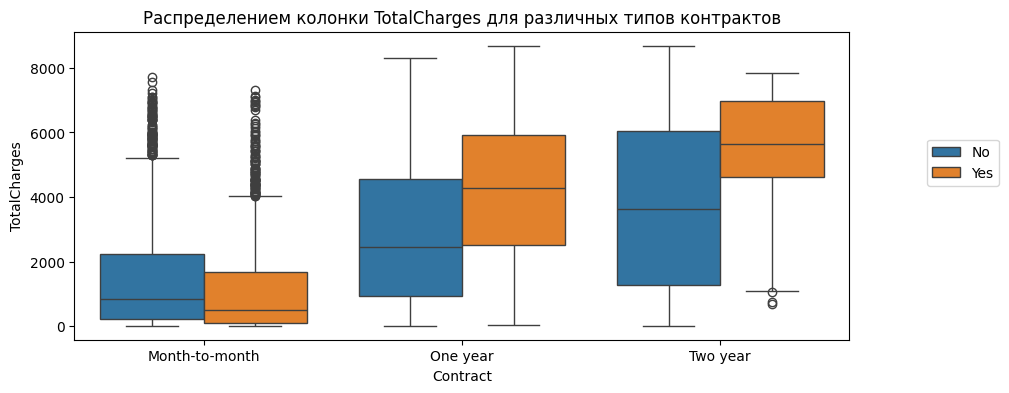

In [9]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df,y='TotalCharges',x='Contract',hue='Churn')
plt.title('Распределением колонки TotalCharges для различных типов контрактов')
plt.legend(loc=(1.1,0.5));

## 2.4 Построим график barplot с корреляцией признаков к целевой переменной (Churn)

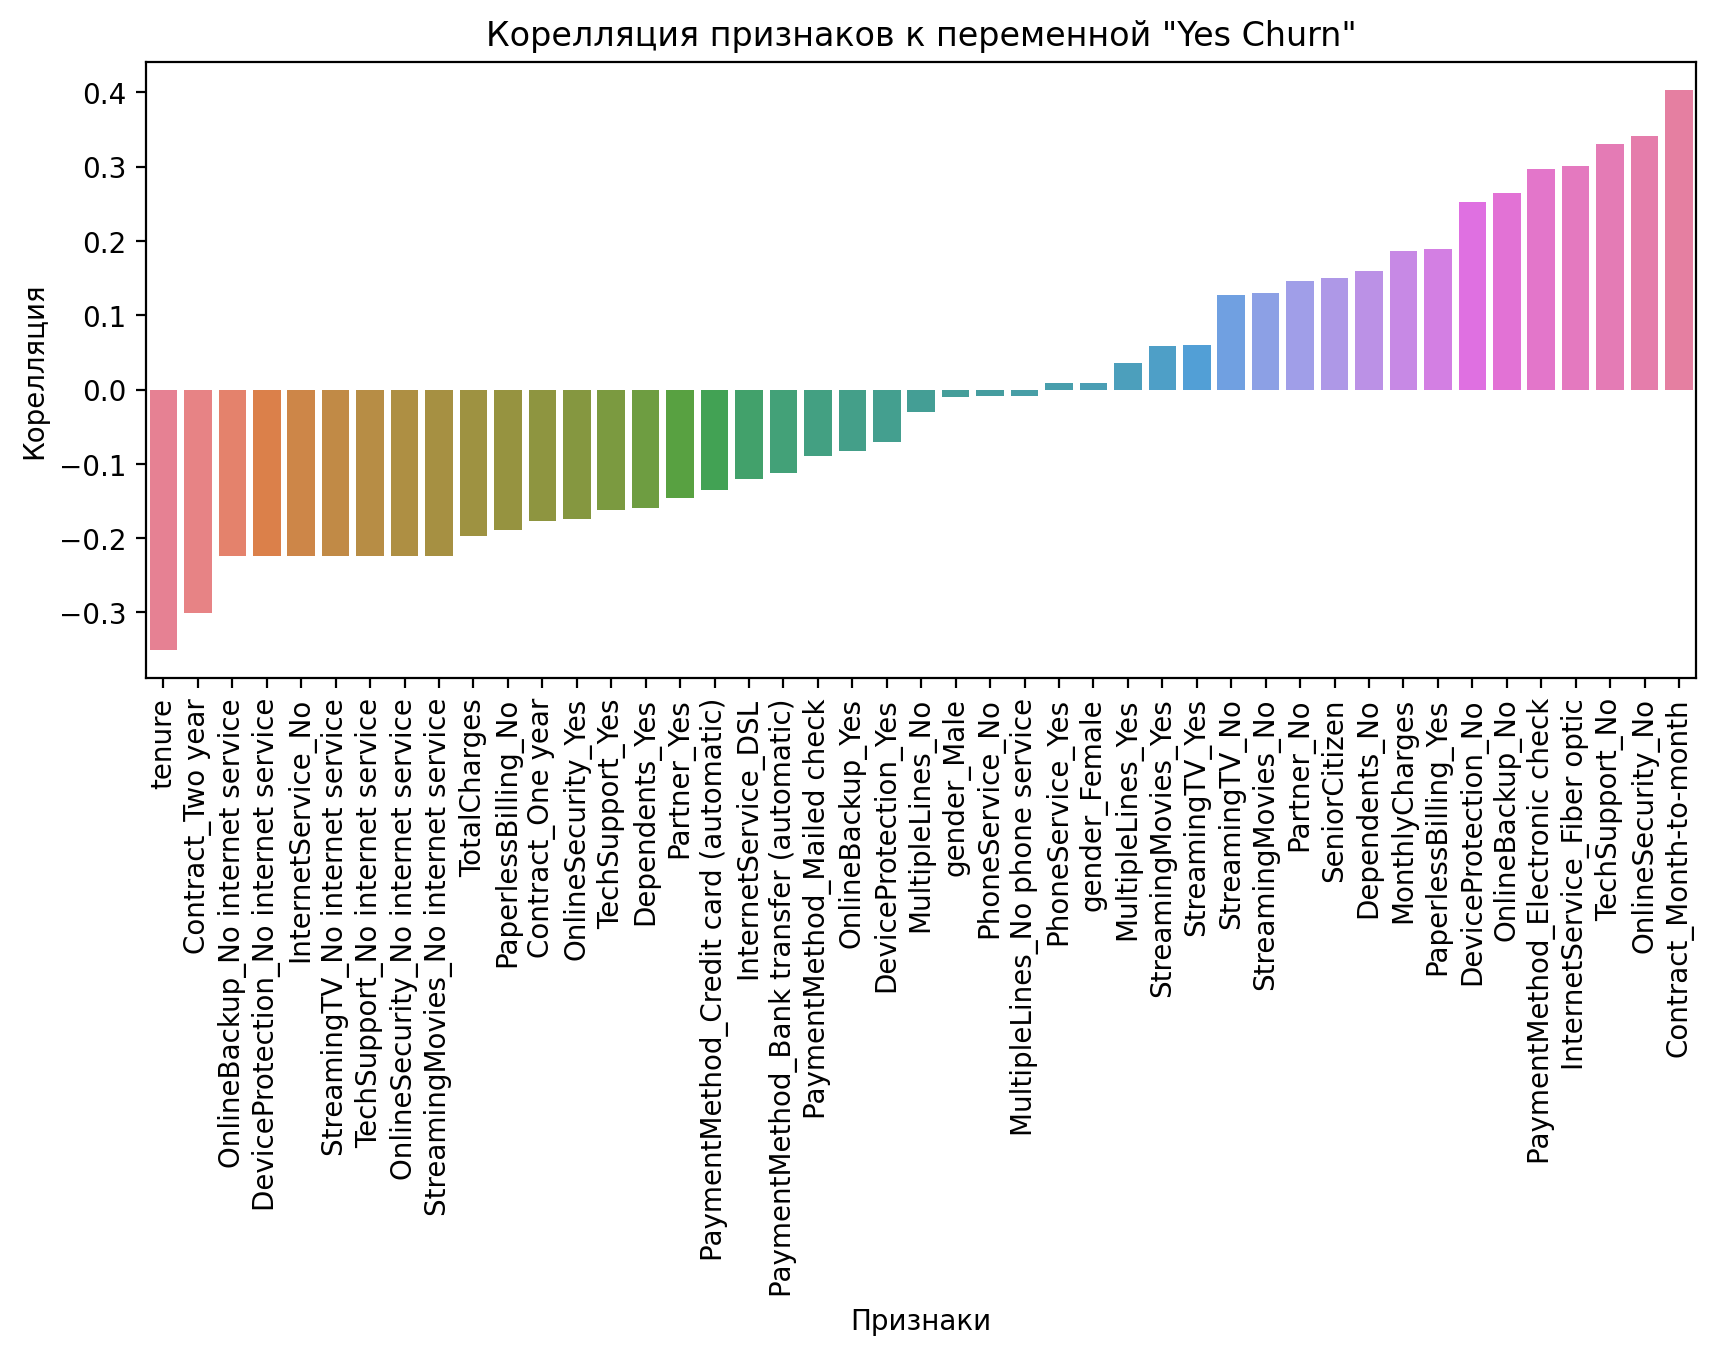

In [10]:
# Создадим новый датафрейм для визуализации
corr_df = pd.get_dummies(df.drop(['customerID'],axis=1)).corr()
corr_df = corr_df['Churn_Yes'].sort_values().iloc[1:-1].reset_index()
corr_df.columns = ['Features', 'Churn_Yes']

# Построим график
plt.figure(figsize=(10, 4), dpi=200)
sns.barplot(data=corr_df, x='Features', y='Churn_Yes', hue='Features')
plt.title('Корелляция признаков к переменной "Yes Churn"')
plt.xlabel('Признаки')
plt.ylabel('Корелляция')
plt.xticks(rotation=90);

## 2.5 Аналитический вывод по итогу исследования зависимостей

По итогу исследования зависимостей признаков на отток клиентов можно сформулировать следующие гипотезы:
 - Сильная обратная корреляция признака **tenure** говорит о том, что большая часть оттока клиентов происходит в первые месяцы обслуживания и отток уменьшается с увеличением продолжительности обслуживания
 - **Contract**: У клиентов с типом контракта "month-to-month" значительно больший отток, чем у клиентов с типом контракта "two-year"
 - На отток клиентов с продолжительным осблуживанием влияет признак **TotalCharges**

## 2.6 Создаим гистограмму с распределением значений колонки tenure - это количество месяцев, сколько времени человек является (или являлся) абонентом компании и ее влияние на отток клиентов

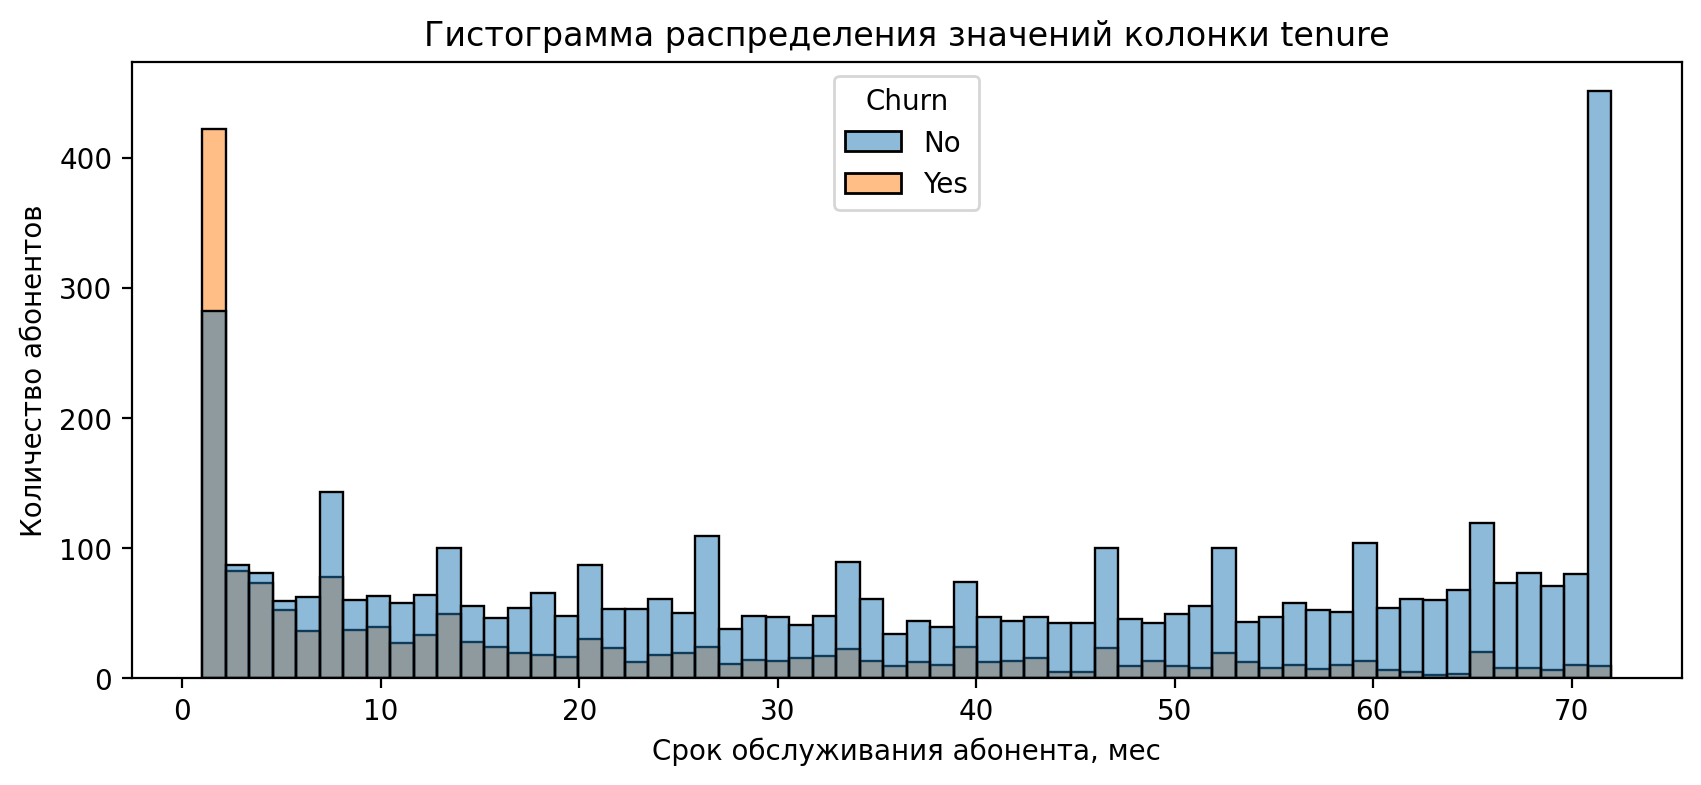

In [11]:
# Построим гистограмму распределения значений колонки tenure
plt.figure(figsize=(10, 4), dpi=200)
sns.histplot(data=df, x='tenure', bins=60, hue='Churn', alpha=0.5)
plt.title('Гистограмма распределения значений колонки tenure')
plt.ylabel('Количество абонентов')
plt.xlabel('Срок обслуживания абонента, мес');

## 2.7 Построим гистограммы для колонки tenure, разбивая данные по двум колонкам - Churn и Contract. 

<Figure size 2000x600 with 0 Axes>

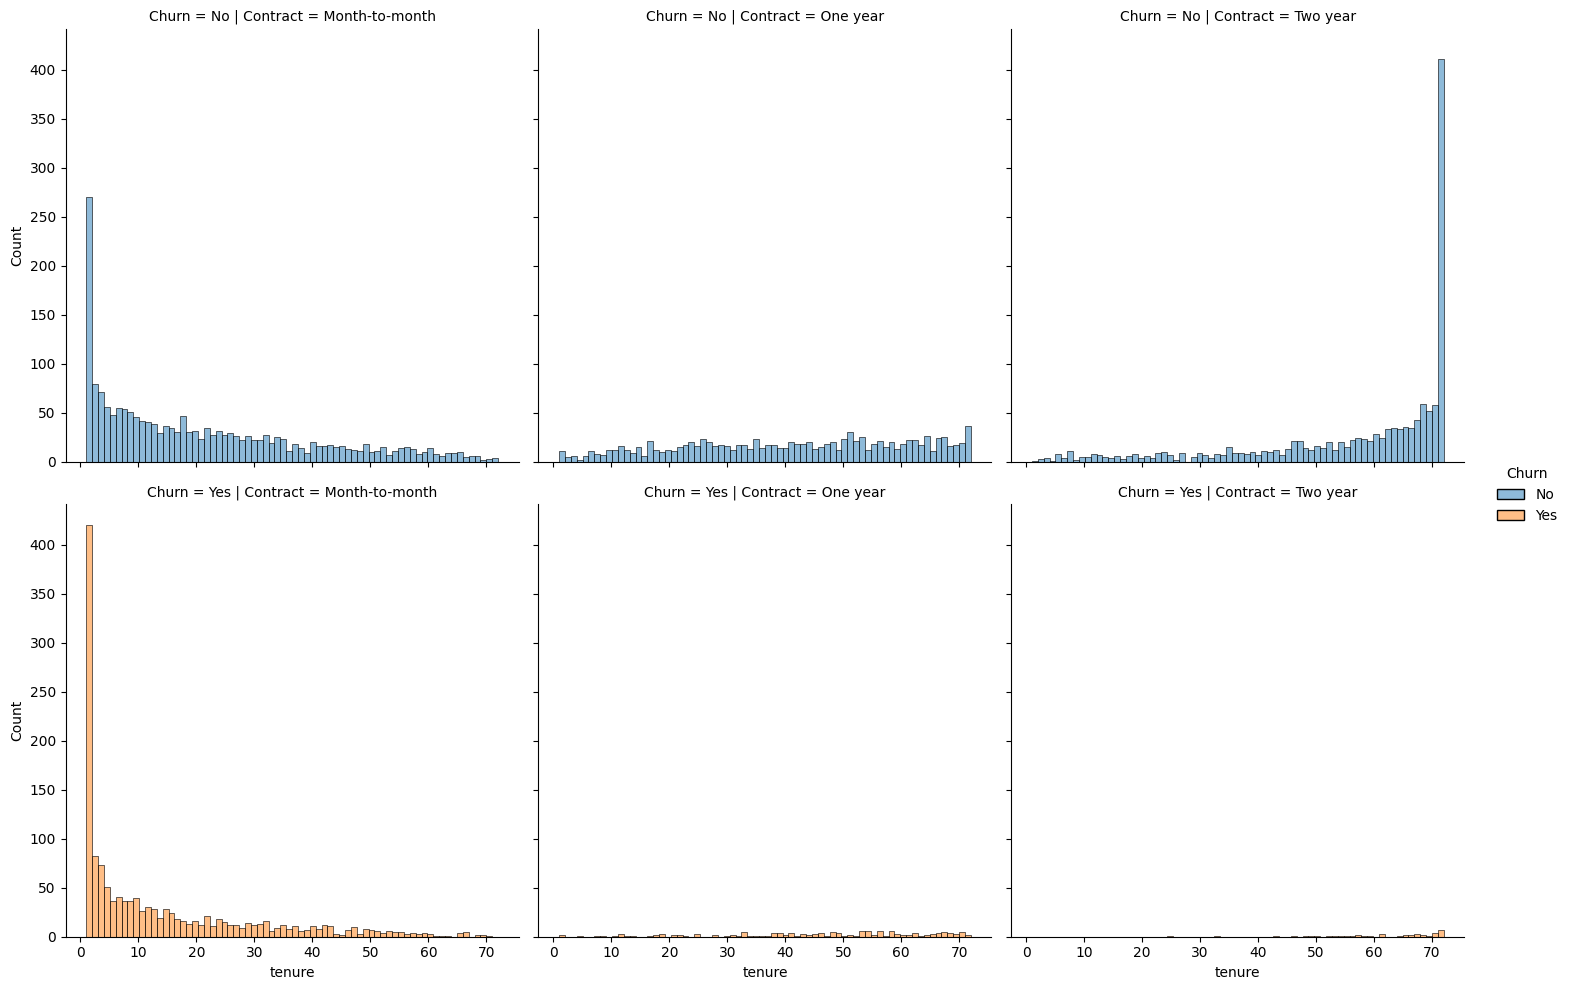

In [12]:
plt.figure(figsize=(10, 3), dpi=200)
sns.displot(data=df, x='tenure', bins=70,
            col='Contract', row='Churn', hue='Churn');

## 2.8 Построим график scatterplot для колонок Total Charges и Monthly Charges

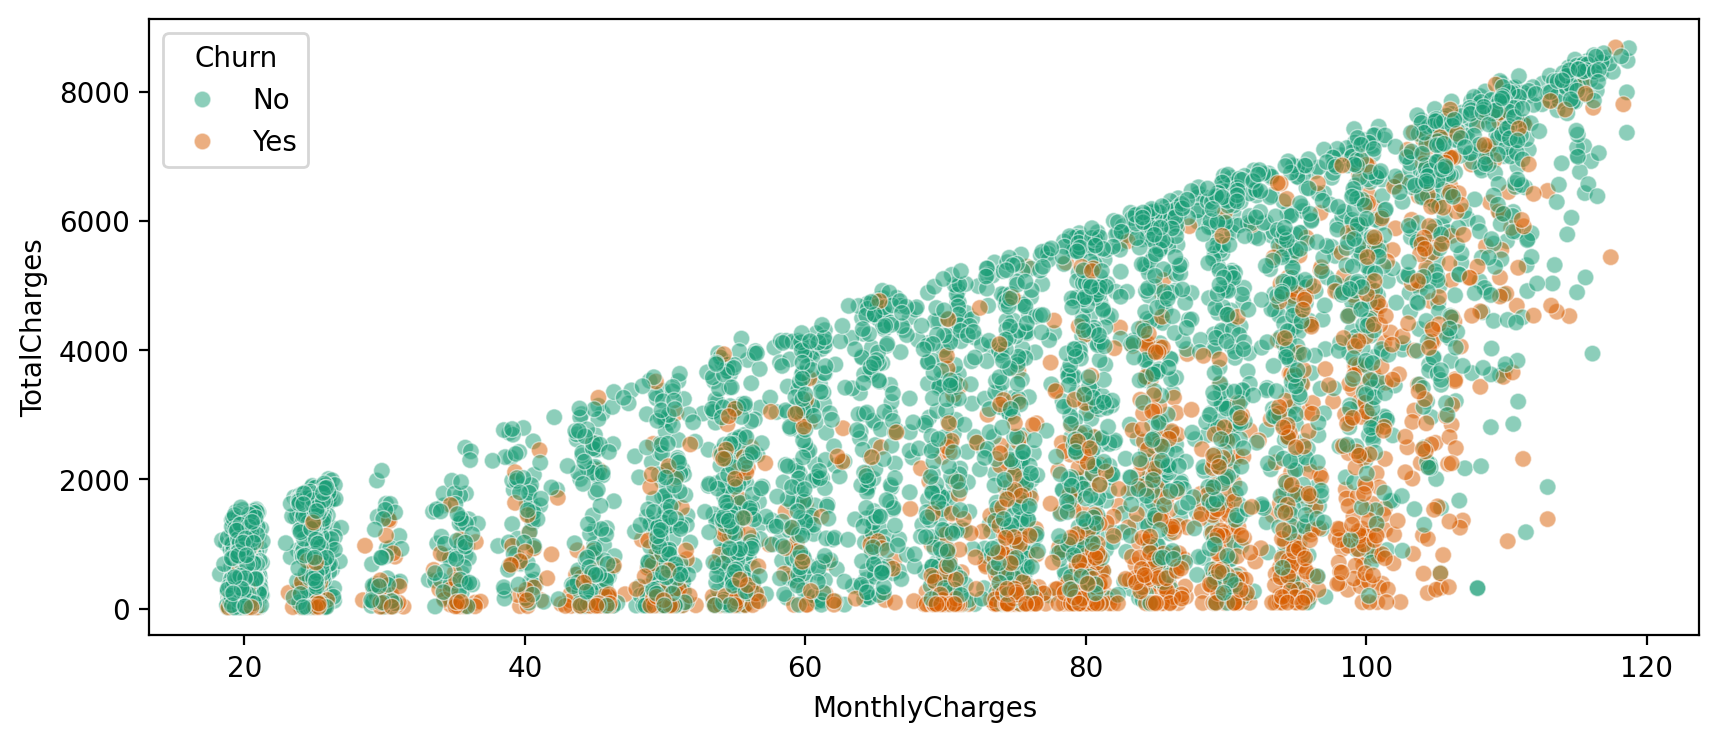

In [13]:
plt.figure(figsize=(10, 4), dpi=200)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges',
                hue='Churn', linewidth=0.5, alpha=0.5, palette='Dark2');

## 2.9 Процент оттока клиентов от общего числа в каждый месяц

Для каждого уникального значения колонки tenure вычислим процент оттока (churn rate) - это количество тех людей, кто ушёл в отток в месяце, как процент от общего количества людей в данном месяце.

In [14]:
no_churn = df.groupby(['Churn', 'tenure']).count().transpose()['No']
yes_churn = df.groupby(['Churn', 'tenure']).count().transpose()['Yes']
churn_rate = 100 * yes_churn / (no_churn+yes_churn)
churn_rate_data = churn_rate.transpose()['customerID'].reset_index()
churn_rate_data.columns = ['tenure', 'churn_rate']
churn_rate_data

,tenure,churn_rate
0,1,62.352941
1,2,53.608247
2,3,48.520710
3,4,47.402597
4,5,46.846847
...,...,...
67,68,8.988764
68,69,7.792208
69,70,11.111111
70,71,3.289474


Text(0.5, 1.0, 'График процента оттока для различных значений tenure')

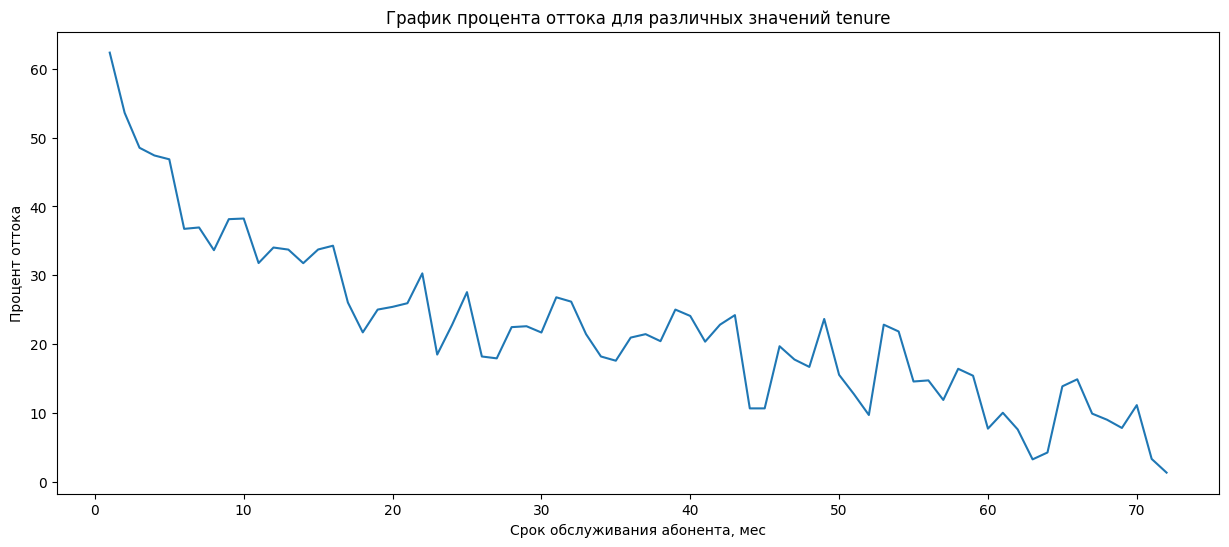

In [15]:
# Построим график процента оттока для различных значений tenure
plt.figure(figsize=(15, 6))
sns.lineplot(data=churn_rate_data, x='tenure', y='churn_rate')
plt.ylabel('Процент оттока')
plt.xlabel('Срок обслуживания абонента, мес')
plt.title('График процента оттока для различных значений tenure')

С увеличением количества месяцев уровень оттока снижается. Очевидно, что чем дольше человек пользуется услугами компании, тем вероятнее то, что его/её всё устраивает, и он/она продолжит пользоваться этими услугами.

## 2.10 Отток клиентов относительно срока обслуживания абонента по категориям

На основе колонки tenure создадим новую колонку с названием "Tenure_category", в которой будут следующие 4 категории:
 - '0-12 месяцев'
 - '12-24 месяцев'
 - '24-48 месяцев'
 - 'Более 48 месяцев' 

In [16]:
df['Tenure_category'] = df['tenure'].apply(
    lambda x: '0-12 месяцев' if x <= 12 else '12-24 месяцев' if x <= 24 else '24-48 месяцев' if x <= 48 else 'Более 48 месяцев')

Text(0.5, 1.0, 'График countplot с количеством ушедших и не ушедших в отток людей в зависмости от срока обслуживания')

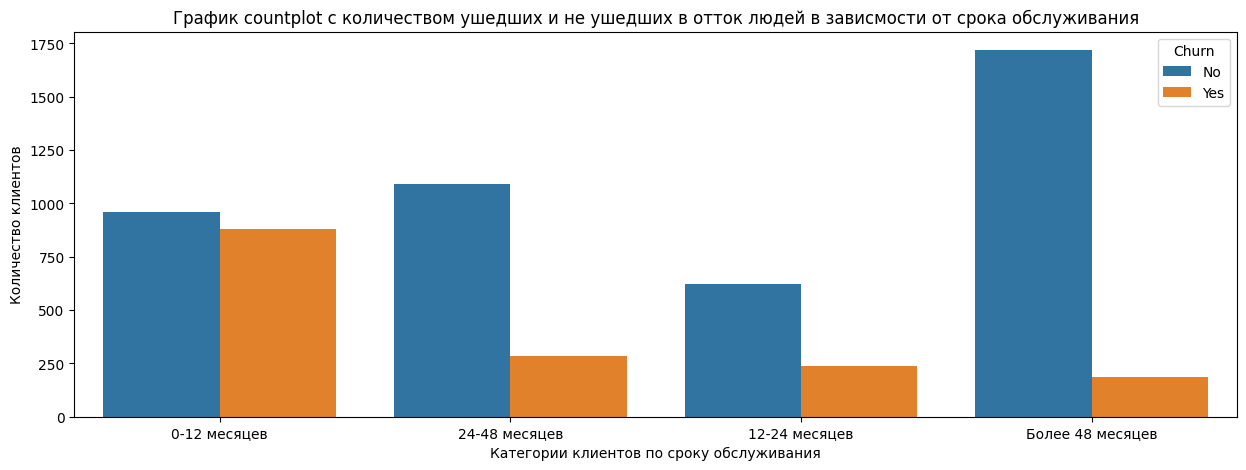

In [17]:
# Построим график countplot с количеством ушедших и не ушедших в отток людей в каждой категории
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x='Tenure_category', hue='Churn')
plt.ylabel('Количество клиентов')
plt.xlabel('Категории клиентов по сроку обслуживания')
plt.title('График countplot с количеством ушедших и не ушедших в отток людей в зависмости от срока обслуживания')

# 3. Построение моделей для прогнозирования оттока

In [18]:
# добавим необхожимые библиотеки
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [19]:
# Разделим все данные на признаки X и целевую переменную Y
X = df.drop(['Churn', 'customerID'], axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df['Churn']

In [20]:
# Разбиение данных на обучающую и тестовую выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

## 3.1 DecisionTreeClassifier

In [21]:
# Определяем сетку параметров
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [2, 3, 5],
    'max_features': ['sqrt', 'log2', None]
}

# Создаем модель
model = DecisionTreeClassifier(random_state=42)

# GridSearchCV
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    return_train_score=True
)

grid.fit(X_train, y_train)

# Лучшие параметры
print("Best parameters:", grid.best_params_)

Best parameters: {'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [22]:
dtc = DecisionTreeClassifier(criterion='entropy', max_depth=6, max_features=None,
                             min_samples_leaf=5, min_samples_split=2, random_state=42)
dtc.fit(X_train, y_train)
dtc_pred = dtc.predict(X_test)

## 3.2 RandomForestClassifier

In [23]:
model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'bootstrap': [True, False],
    'oob_score': [True],
    'max_features': [2, 3, 4]}

# Создание GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

# Запуск поиска
grid_search.fit(X_train, y_train)

# Лучшие параметры
print("Best parameters:", grid_search.best_params_)

Best parameters: {'bootstrap': True, 'max_features': 3, 'n_estimators': 200, 'oob_score': True}


In [24]:
rfc = RandomForestClassifier(
    bootstrap=True, max_features=3, n_estimators=200, oob_score=True, random_state=42)

rfc.fit(X_train,y_train)

rfc_pred = rfc.predict(X_test)

## 3.3 AdaBoostClassifier

In [25]:
# Grid Search с настройкой DecisionTree в качестве базового классификатора
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.5, 1.0],
    
    # Параметры базового дерева
    'estimator__max_depth': [1, 2, 4],
    'estimator__min_samples_split': [2, 3, 4],
    'estimator__min_samples_leaf': [1, 2]
}


base_tree = DecisionTreeClassifier(random_state=42)

# Создание модели для GridSearch
ada_for_grid = AdaBoostClassifier(
    estimator=base_tree,
    random_state=42
)

# Поиск по сетке
grid_search_ada = GridSearchCV(
    estimator=ada_for_grid,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_ada.fit(X_train, y_train)

# Лучшие параметры
print("Лучшие параметры:", grid_search_ada.best_params_)

Лучшие параметры: {'estimator__max_depth': 4, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 3, 'learning_rate': 0.5, 'n_estimators': 50}


In [26]:
ada = grid_search_ada.best_estimator_
ada_pred = ada.predict(X_test)

## 3.4 GradientBoostingClassifier

In [27]:
# Параметрическая сетка
param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0]
}

# Создание модели
gb_base = GradientBoostingClassifier(random_state=42)

# Поиск по сетке с кросс-валидацией
grid_search_gbc = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search_gbc.fit(X_train, y_train)

# Результаты
print("Лучшие параметры:", grid_search_gbc.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 150, 'subsample': 0.8}


In [38]:
gbc = grid_search_gbc.best_estimator_
gbc_pred = gbc.predict(X_test)

# 4. Сравнение качества моделей

## 4.1 Сравнение accuracy scores

In [39]:
print(f'DecisionTreeClassifier accuracy: {accuracy_score(y_test, dtc_pred)}')
print(f'RandomForestClassifier accuracy: {accuracy_score(y_test, rfc_pred)}')
print(f'AdaBoostClassifier accuracy: {accuracy_score(y_test, ada_pred)}')
print(f'GradientBoostingClassifier accuracy: {accuracy_score(y_test, gbc_pred)}')

DecisionTreeClassifier accuracy: 0.7809364548494984
RandomForestClassifier accuracy: 0.8160535117056856
AdaBoostClassifier accuracy: 0.8010033444816054
GradientBoostingClassifier accuracy: 0.822742474916388


## 4.2 DecisionTreeClassifier scores

In [40]:
print(classification_report(y_test, dtc_pred))

              precision    recall  f1-score   support

          No       0.87      0.84      0.85       448
         Yes       0.56      0.61      0.58       150

    accuracy                           0.78       598
   macro avg       0.71      0.73      0.72       598
weighted avg       0.79      0.78      0.78       598



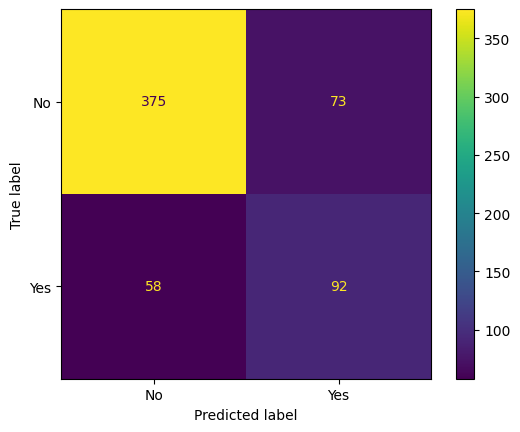

In [41]:
ConfusionMatrixDisplay.from_estimator(grid, X_test, y_test);

## 4.3 RandomForestClassifier scores

In [42]:
print(classification_report(y_test, rfc_pred))

              precision    recall  f1-score   support

          No       0.85      0.92      0.88       448
         Yes       0.68      0.51      0.58       150

    accuracy                           0.82       598
   macro avg       0.76      0.71      0.73       598
weighted avg       0.81      0.82      0.81       598



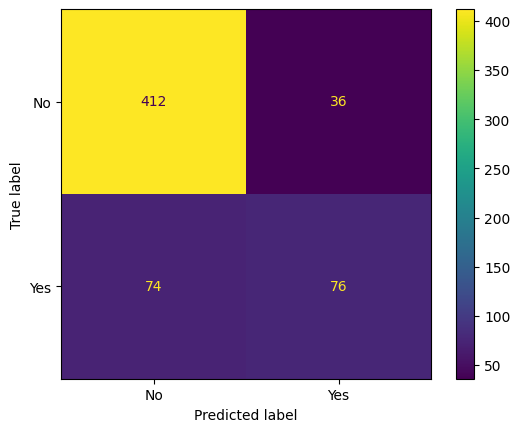

In [43]:
ConfusionMatrixDisplay.from_estimator(grid_search, X_test, y_test);

## 4.4 AdaBoostClassifier scores

In [44]:
print(classification_report(y_test, ada_pred))

              precision    recall  f1-score   support

          No       0.86      0.88      0.87       448
         Yes       0.61      0.57      0.59       150

    accuracy                           0.80       598
   macro avg       0.73      0.73      0.73       598
weighted avg       0.80      0.80      0.80       598



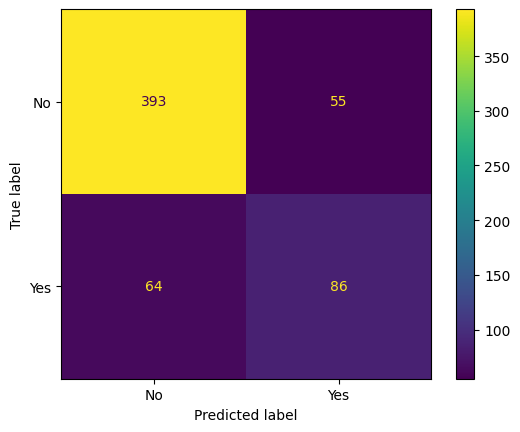

In [45]:
ConfusionMatrixDisplay.from_estimator(grid_search_ada, X_test, y_test);

## 4.5 GradientBoostingClassifier scores

In [46]:
print(classification_report(y_test, gbc_pred))

              precision    recall  f1-score   support

          No       0.87      0.90      0.88       448
         Yes       0.66      0.60      0.63       150

    accuracy                           0.82       598
   macro avg       0.77      0.75      0.76       598
weighted avg       0.82      0.82      0.82       598



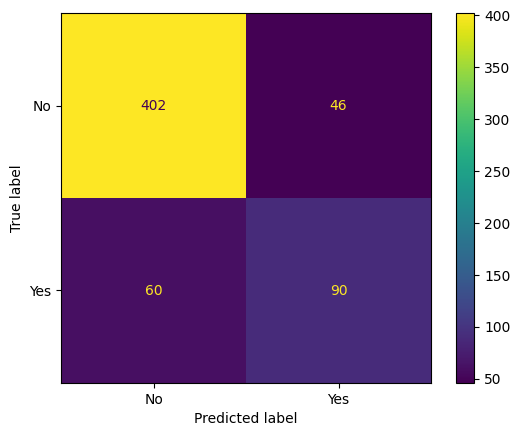

In [47]:
ConfusionMatrixDisplay.from_estimator(grid_search_gbc, X_test, y_test);

## 4.6 Выводы по качеству моделей

Были получены лучшие результаты в модели **GradientBoostingClassifier**.
Однако, модели получили схожие результаты. При других параметрах random_state или других параметрах GridSearch более эффективной может стать другая модель